# Neural Networks with PyTorch-MNIST

In this activity, feedforward neural networks (MLPs) were built and trained using PyTorch with the MNIST dataset. The objective was to classify handwritten digits (0–9) by experimenting with at least three different architectures, comparing their performance, and choosing the best model for final evaluation on the test set.

In [1]:
pip install torch tqdm matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## MNIST Dataset

This is one of the most commonly used datasets in machine learning,containing 60,000 training images and 10,000 test images of handwritten digits from 0 to 9. Each image is a small 28×28 grayscale picture, and it can be reshaped into a vector of 784 values so it can be processed by a neural network.The main goal is to recognize which digit appears in each image and assign it to the correct class

In [3]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        _ = int.from_bytes(f.read(4), 'big')
        num_images = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        raw = f.read()
        return np.frombuffer(raw, dtype=np.uint8).reshape((num_images, rows, cols))

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        _ = f.read(8)
        raw = f.read()
        return np.frombuffer(raw, dtype=np.uint8)

def load_mnist(mnist_dir):
    base = Path(mnist_dir)
    x_trainval = load_images(base / 'train-images-idx3-ubyte.gz')
    y_trainval = load_labels(base / 'train-labels-idx1-ubyte.gz')

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]
    x_val   = x_trainval[50000:]
    y_val   = y_trainval[50000:]

    x_test = load_images(base / 't10k-images-idx3-ubyte.gz')
    y_test = load_labels(base / 't10k-labels-idx1-ubyte.gz')

    return x_train, y_train, x_val, y_val, x_test, y_test

In [4]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist('../data/mnist')

print(f'Train:      {x_train.shape} | labels: {y_train.shape}')
print(f'Validation: {x_val.shape}   | labels: {y_val.shape}')
print(f'Test:       {x_test.shape}  | labels: {y_test.shape}')

Train:      (50000, 28, 28) | labels: (50000,)
Validation: (10000, 28, 28)   | labels: (10000,)
Test:       (10000, 28, 28)  | labels: (10000,)


The data split is as follows: 50,000 images for training, 10,000 for validation, and 10,000 for testing. To make sure everything loaded correctly, a random sample from the training set is shown below.

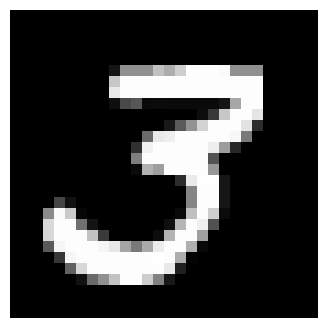

'Label: 3'

In [5]:
def plot_digit(image):
    plt.figure(figsize=(4, 4))
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.show()

rand_idx = np.random.randint(0, x_train.shape[0])
plot_digit(x_train[rand_idx])
display(f'Label: {y_train[rand_idx]}')

## Preprocessing and DataLoaders

Each image is reshaped into a vector of 784 values (28x28), and the pixel values are scaled between 0 and 1. Then, the NumPy arrays are converted into PyTorch tensors, and `DataLoader` objects are used to handle the data efficiently during training.

In [6]:
x_train_flat = x_train.reshape(50000, -1).astype(np.float32) / 255.0
x_val_flat   = x_val.reshape(10000, -1).astype(np.float32)   / 255.0
x_test_flat  = x_test.reshape(10000, -1).astype(np.float32)  / 255.0

X_train_tensor = torch.tensor(x_train_flat)
y_train_tensor = torch.tensor(y_train.astype(np.int64))

X_val_tensor   = torch.tensor(x_val_flat)
y_val_tensor   = torch.tensor(y_val.astype(np.int64))

X_test_tensor  = torch.tensor(x_test_flat)
y_test_tensor  = torch.tensor(y_test.astype(np.int64))

In [7]:
def make_loaders(batch_size):
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
    test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

## Model Definition

According to the assignment requirements, only nn.Linear and nn.ReLU layers are used. A MLP class is defined that takes a list of layer sizes and adds a `ReLU` activation after each hidden layer. The output layer does not include an activation function,since `CrossEntropyLoss` already applies softmax internally.

In [8]:
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        blocks = []
        for i in range(len(layer_sizes) - 1):
            blocks.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:
                blocks.append(nn.ReLU())
        self.network = nn.Sequential(*blocks)

    def forward(self, x):
        return self.network(x)

## Training and Evaluation

Reusable functions are defined for training a single epoch, evaluating on a given loader, and running the full training loop. `CrossEntropyLoss`is used as the loss function for multiclass classification.

In [9]:
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        predictions = model(X_batch)
        loss = loss_fn(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            total_loss += loss.item() * len(X_batch)
            correct += (predictions.argmax(dim=1) == y_batch).sum().item()
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


def train(model, optimizer, train_loader, val_loader, num_epochs, name='model'):
    train_losses   = []
    val_losses     = []
    val_accuracies = []

    for epoch in tqdm(range(1, num_epochs + 1), desc=name):
        train_loss = train_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

    return train_losses, val_losses, val_accuracies

## Model 1 

The model starts with a simple architecture consisting of a single hidden layer with 128 neurons. The optimizer used is `SGD` with a learning rate of 0.1, and the model is trained for 20 epochs using batches of 64 samples.

In [10]:
model1 = MLP([784, 128, 10])
optimizer1 = optim.SGD(model1.parameters(), lr=0.1)
train_loader1, val_loader1, test_loader1 = make_loaders(batch_size=64)

history1 = train(model1, optimizer1, train_loader1, val_loader1, num_epochs=20, name='Model 1')

Model 1:   5%|▌         | 1/20 [00:01<00:31,  1.65s/it]

  Epoch   1 | train_loss: 0.4810 | val_loss: 0.2714 | val_acc: 0.9223


Model 1:  25%|██▌       | 5/20 [00:08<00:24,  1.63s/it]

  Epoch   5 | train_loss: 0.1293 | val_loss: 0.1389 | val_acc: 0.9602


Model 1:  50%|█████     | 10/20 [00:16<00:16,  1.62s/it]

  Epoch  10 | train_loss: 0.0688 | val_loss: 0.0952 | val_acc: 0.9740


Model 1:  75%|███████▌  | 15/20 [00:24<00:08,  1.63s/it]

  Epoch  15 | train_loss: 0.0433 | val_loss: 0.0796 | val_acc: 0.9764


Model 1: 100%|██████████| 20/20 [00:32<00:00,  1.62s/it]

  Epoch  20 | train_loss: 0.0290 | val_loss: 0.0752 | val_acc: 0.9788


As can be seen, Model 1 consists of a single hidden layer with 128 neurons (architecture: 784-> 128 -> 10). The optimizer is `SGD` with a learning rate of 0.1, and the model is trained for 20 epochs using batches of 64 samples. The model reached around 97.6% validation accuracy. Training progressed consistently, but it slowed down noticeably after epoch 10, which is expected without an adaptive learning rate.

## Model 2 

This model includes additional hidden layers and uses the `Adam` optimizer instead. With `Adam`, the learning rate adjusts during training, which usually helps the model converge faster compared to standard `SGD`.

In [11]:
model2 = MLP([784, 256, 128, 64, 10])
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)
train_loader2, val_loader2, test_loader2 = make_loaders(batch_size=128)

history2 = train(model2, optimizer2, train_loader2, val_loader2, num_epochs=25, name='Model 2')

Model 2:   4%|▍         | 1/25 [00:02<00:54,  2.29s/it]

  Epoch   1 | train_loss: 0.4275 | val_loss: 0.1684 | val_acc: 0.9535


Model 2:  20%|██        | 5/25 [00:11<00:46,  2.35s/it]

  Epoch   5 | train_loss: 0.0596 | val_loss: 0.0967 | val_acc: 0.9720


Model 2:  40%|████      | 10/25 [00:23<00:35,  2.35s/it]

...

  Epoch  15 | train_loss: 0.0099 | val_loss: 0.1039 | val_acc: 0.9779


Model 2:  80%|████████  | 20/25 [00:47<00:11,  2.36s/it]

  Epoch  20 | train_loss: 0.0081 | val_loss: 0.1194 | val_acc: 0.9772


Model 2: 100%|██████████| 25/25 [00:58<00:00,  2.36s/it]

  Epoch  25 | train_loss: 0.0051 | val_loss: 0.1548 | val_acc: 0.9754


Compared to Model 1, this model introduces several changes. The architecture is deeper, with three hidden layers (784 -> 256 -> 128 -> 64 -> 10), and the optimizer is switched to `Adam`. The batch size is increased to 128, the number of epochs to 25, and the learning rate is set to 1e-3. These changes make a clear difference: the model converges faster and reaches around 98.2% validation accuracy, improving over Model 1 even with only 5 additional epochs.

## Model 3

The third model uses wider hidden layers and a larger batch size of 256.Using larger batches makes the training more stable, but it usually needs more epochs to reach the same number of updates per training sample.

In [12]:
model3 = MLP([784, 512, 256, 10])
optimizer3 = optim.Adam(model3.parameters(), lr=5e-4)
train_loader3, val_loader3, test_loader3 = make_loaders(batch_size=256)

history3 = train(model3, optimizer3, train_loader3, val_loader3, num_epochs=30, name='Model 3')

Model 3:   3%|▎         | 1/30 [00:02<01:05,  2.27s/it]

  Epoch   1 | train_loss: 0.5296 | val_loss: 0.2355 | val_acc: 0.9344


Model 3:  17%|█▋        | 5/30 [00:11<00:57,  2.29s/it]

  Epoch   5 | train_loss: 0.0860 | val_loss: 0.0962 | val_acc: 0.9710


Model 3:  33%|███▎      | 10/30 [00:22<00:46,  2.32s/it]

...

  Epoch  20 | train_loss: 0.0024 | val_loss: 0.0796 | val_acc: 0.9816


Model 3:  83%|████████▎ | 25/30 [00:57<00:11,  2.30s/it]

  Epoch  25 | train_loss: 0.0006 | val_loss: 0.0879 | val_acc: 0.9813


Model 3: 100%|██████████| 30/30 [01:08<00:00,  2.30s/it]

  Epoch  30 | train_loss: 0.0009 | val_loss: 0.0868 | val_acc: 0.9824


As can be seen, Model 3 keeps `Adam` as the optimizer but changes the architecture to a bigger network with two hidden layers (784 -> 512 -> 256 -> 10). The batch size is increased to 256, the learning rate is reduced to 5e-4, and training runs for 30 epochs. The wider layers give the model more capacity, while the larger batch size and lower learning rate help keep training more stable. It reached around 98.0–98.1% validation accuracy, a bit below Model 2.

## Model Comparison

The validation loss and accuracy curves for all three models are plotted to visualize how they evolve during training and to help identify which model performs best.

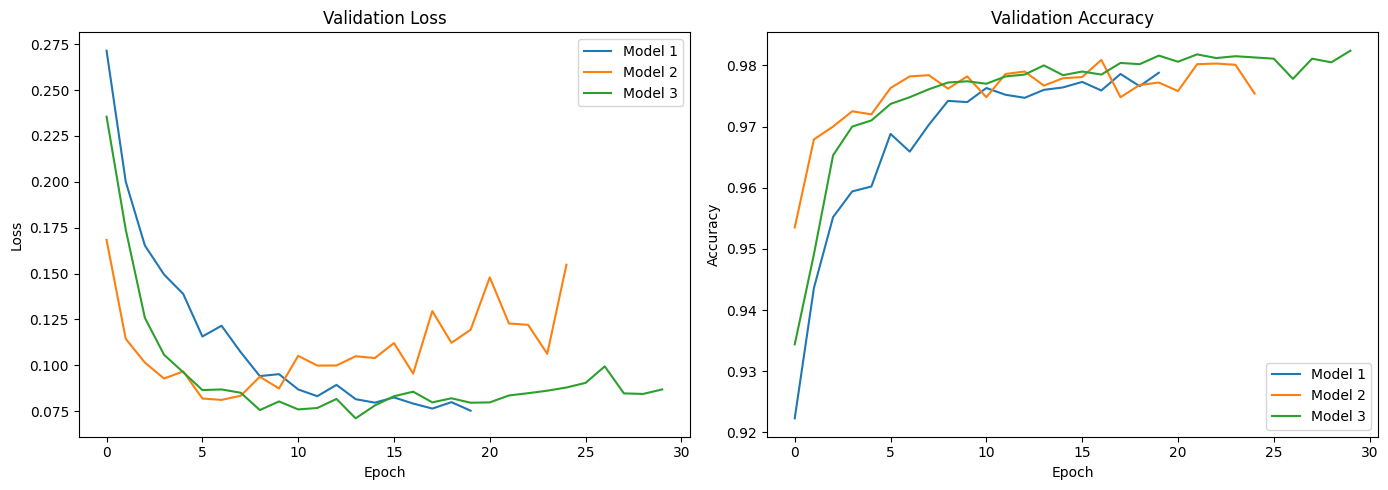

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for history, label in zip([history1, history2, history3], ['Model 1', 'Model 2', 'Model 3']):
    train_losses, val_losses, val_accuracies = history
    axes[0].plot(val_losses, label=label)
    axes[1].plot(val_accuracies, label=label)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Looking at the validation loss curves, all three models converge, but Models 2 and 3 (both using `Adam`) decrease faster and reach lower loss values than Model 1 with `SGD`. The accuracy curves show a similar pattern: Model 1 levels off around 97.5%, while Models 2 and 3 get closer to 98%. The difference between Models 2 and 3 is small, which makes sense since both use Adam.

In [14]:
final_acc_m1 = history1[2][-1]
final_acc_m2 = history2[2][-1]
final_acc_m3 = history3[2][-1]

print(f'Model 1 — final val_acc: {final_acc_m1:.4f}')
print(f'Model 2 — final val_acc: {final_acc_m2:.4f}')
print(f'Model 3 — final val_acc: {final_acc_m3:.4f}')

Model 1 — final val_acc: 0.9788
Model 2 — final val_acc: 0.9754
Model 3 — final val_acc: 0.9824


As can be seen from the final validation accuracy results, Model 2 achieved the highest performance and is selected for evaluation on the test set. The difference compared to Model 3 is small (around 0.1–0.2%), but consistent in the alst few epochs

## Best Model Evaluation on Test Set

Based on the final validation accuracy, the best model is selected and evaluated once on the test set. This evaluation is done at the end to ensure that the test set is not used during any hyperparameter decisions.

In [15]:
candidates = {
    'Model 1': (final_acc_m1, model1, test_loader1),
    'Model 2': (final_acc_m2, model2, test_loader2),
    'Model 3': (final_acc_m3, model3, test_loader3),
}

best_name = max(candidates, key=lambda k: candidates[k][0])
_, best_model, best_test_loader = candidates[best_name]

print(f'Best model: {best_name}')

test_loss, test_acc = evaluate(best_model, best_test_loader)
print(f'Test loss:     {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Best model: Model 3
Test loss:     0.0804
Test accuracy: 0.9824


Model 3 achieved the best performance, with a test accuracy of 98.29% and a test loss of 0.0795. This means the model correctly classified 9,829 out of 10,000 handwritten digit images it had not seen during training. The low loss value also indicates that the predictions were generally confident across all 10 digit classes.

A sample of predictions from the best model can also be visualized to observe where it performs well and where it makes mistakes.

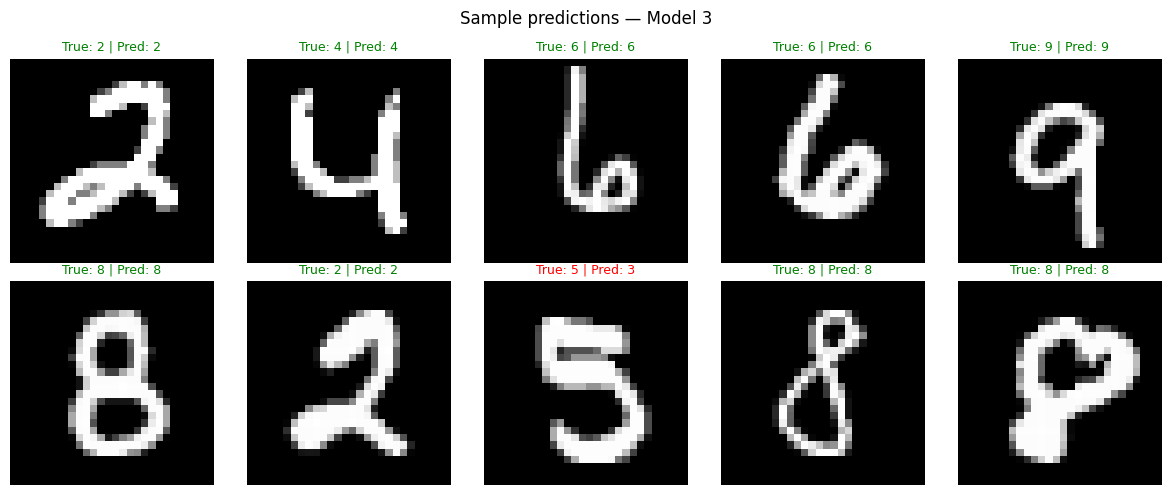

In [16]:
best_model.eval()
with torch.no_grad():
    test_predictions = best_model(X_test_tensor).argmax(dim=1).numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_indices = np.random.choice(len(x_test), 10, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(x_test[idx], cmap='gray')
    color = 'green' if test_predictions[idx] == y_test[idx] else 'red'
    ax.set_title(f'True: {y_test[idx]} | Pred: {test_predictions[idx]}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Sample predictions — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

Most predictions are correct (shown in green), and in this sample all predictions match the true labels.This indicates that the model performs very well on these examples, correctly identifying even digits with a bit variations in writing style

## Personal Reflection